# Quantum Machine Learning (AIMLCZG545)
## Assignment 1 - Part A: Quantum Circuit Design

**Student Name:** Ayushi Gupta
**Student ID:** 2024ac05720

In [9]:
import subprocess, sys, importlib

def install_if_missing(packages):
    for pkg in packages:
        try:
            __import__(pkg)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
            importlib.invalidate_caches()

install_if_missing(["qiskit", "matplotlib", "numpy", "pylatexenc"])

# qiskit-aer uses 'qiskit_aer' as import name
try:
    import qiskit_aer
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "qiskit-aer", "--quiet"])
    importlib.invalidate_caches()

# Verify pylatexenc is importable
import pylatexenc
print("All required libraries are available.")

All required libraries are available.


In [10]:
# Import required libraries
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

---
## Problem 1: Controlled Probability Design

**Goal:** Design a single-qubit circuit such that P(0) ≈ 0.75, P(1) ≈ 0.25

**Constraints:**
- Initial state: |0⟩
- Allowed gates: H, X, Ry, Rz

### a) Rotation angle and mathematical justification

We use the $R_y(\theta)$ gate. The $R_y$ gate applied to $|0\rangle$ gives:

$$R_y(\theta)|0\rangle = \cos\left(\frac{\theta}{2}\right)|0\rangle + \sin\left(\frac{\theta}{2}\right)|1\rangle$$

The probabilities are:
- $P(0) = \cos^2(\theta/2)$
- $P(1) = \sin^2(\theta/2)$

We need $P(0) = 0.75$ and $P(1) = 0.25$:

$$\cos^2(\theta/2) = 0.75 \implies \cos(\theta/2) = \frac{\sqrt{3}}{2} \implies \theta/2 = \pi/6$$

$$\therefore \theta = \pi/3 \approx 1.0472 \text{ radians}$$

**Verification:** $\cos^2(\pi/6) = (\sqrt{3}/2)^2 = 3/4 = 0.75$ ✓  
$\sin^2(\pi/6) = (1/2)^2 = 1/4 = 0.25$ ✓

Problem 1: Single-qubit circuit with Ry(pi/3)


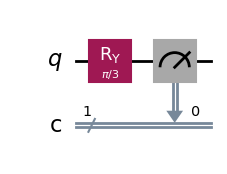

In [11]:
# b) & c) Build and draw the quantum circuit, then show measurement results

theta = np.pi / 3  # Rotation angle

qc1 = QuantumCircuit(1, 1)
qc1.ry(theta, 0)
qc1.measure(0, 0)

# Draw the circuit
print("Problem 1: Single-qubit circuit with Ry(pi/3)")
qc1.draw('mpl')

Measurement results (1024 shots):
{'0': 748, '1': 276}


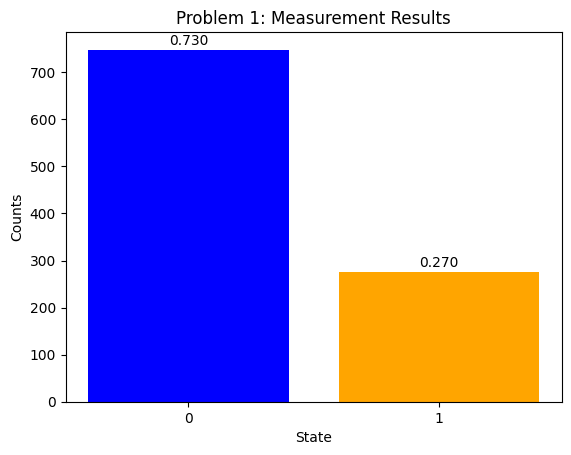


P(0) = 0.7305 (expected: 0.75)
P(1) = 0.2695 (expected: 0.25)


In [12]:
# c) Measurement results using Sampler
sampler = StatevectorSampler()
job = sampler.run([qc1], shots=1024)
result = job.result()
counts = result[0].data.c.get_counts()

print("Measurement results (1024 shots):")
print(counts)

# Plot histogram
labels = list(counts.keys())
values = list(counts.values())
plt.bar(labels, values, color=['blue', 'orange'])
plt.xlabel('State')
plt.ylabel('Counts')
plt.title('Problem 1: Measurement Results')
for i, v in enumerate(values):
    plt.text(i, v + 10, f'{v/1024:.3f}', ha='center')
plt.show()

print(f"\nP(0) = {counts.get('0', 0)/1024:.4f} (expected: 0.75)")
print(f"P(1) = {counts.get('1', 0)/1024:.4f} (expected: 0.25)")

### d) Explanation

The circuit produces the desired probabilities as follows:

1. We start with the qubit in state $|0\rangle$.
2. We apply the $R_y(\pi/3)$ rotation gate, which rotates the qubit state on the Bloch sphere around the Y-axis by $\pi/3$ radians.
3. After rotation, the state becomes: $\cos(\pi/6)|0\rangle + \sin(\pi/6)|1\rangle = \frac{\sqrt{3}}{2}|0\rangle + \frac{1}{2}|1\rangle$
4. Upon measurement, the probability of observing $|0\rangle$ is $|\sqrt{3}/2|^2 = 3/4 = 0.75$ and the probability of observing $|1\rangle$ is $|1/2|^2 = 1/4 = 0.25$.

The $R_y$ gate provides precise control over measurement probabilities through its rotation angle, making it ideal for engineering specific probability distributions.

---
## Problem 2: Phase vs Measurement

**Goal:** Design two circuits where final states differ due to phase but measurement probabilities are identical.

Circuit 1: H gate (produces |+> state)


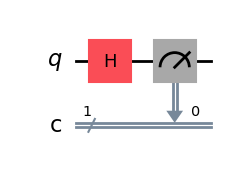


Circuit 2: H + Z gates (produces |-> state)


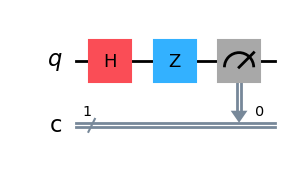

In [13]:
# a) Circuit 1: H gate only (creates |+> state)
qc2a = QuantumCircuit(1, 1)
qc2a.h(0)
qc2a.measure(0, 0)

# Circuit 2: H gate followed by Z gate (creates |-> state)
qc2b = QuantumCircuit(1, 1)
qc2b.h(0)
qc2b.z(0)
qc2b.measure(0, 0)

print("Circuit 1: H gate (produces |+> state)")
display(qc2a.draw('mpl'))

print("\nCircuit 2: H + Z gates (produces |-> state)")
display(qc2b.draw('mpl'))

Circuit 1 (|+>) counts: {'0': 511, '1': 513}
Circuit 2 (|->) counts: {'0': 517, '1': 507}


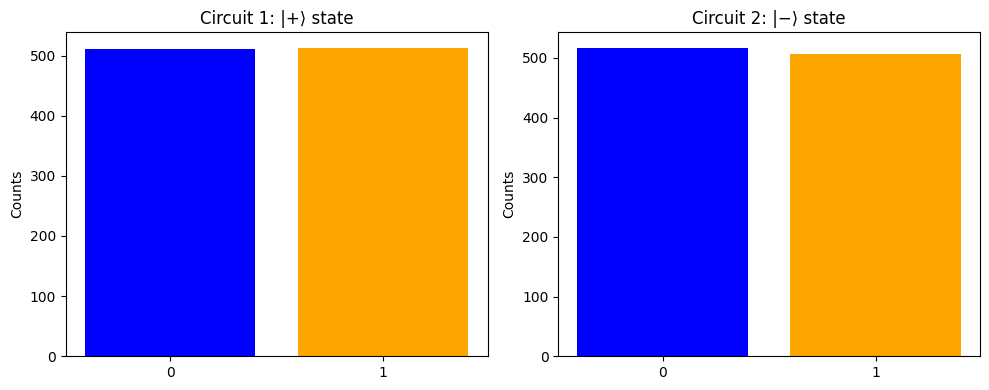

In [14]:
# b) Show output distributions
sampler = StatevectorSampler()

# Run Circuit 1
job1 = sampler.run([qc2a], shots=1024)
result1 = job1.result()
counts1 = result1[0].data.c.get_counts()

# Run Circuit 2
job2 = sampler.run([qc2b], shots=1024)
result2 = job2.result()
counts2 = result2[0].data.c.get_counts()

print("Circuit 1 (|+>) counts:", counts1)
print("Circuit 2 (|->) counts:", counts2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(counts1.keys(), counts1.values(), color=['blue', 'orange'])
axes[0].set_title('Circuit 1: |+⟩ state')
axes[0].set_ylabel('Counts')
axes[1].bar(counts2.keys(), counts2.values(), color=['blue', 'orange'])
axes[1].set_title('Circuit 2: |−⟩ state')
axes[1].set_ylabel('Counts')
plt.tight_layout()
plt.show()

In [15]:
# Show the statevectors to illustrate the phase difference
qc2a_sv = QuantumCircuit(1)
qc2a_sv.h(0)

qc2b_sv = QuantumCircuit(1)
qc2b_sv.h(0)
qc2b_sv.z(0)

sv1 = Statevector.from_instruction(qc2a_sv)
sv2 = Statevector.from_instruction(qc2b_sv)

print("Statevector of Circuit 1 (|+>):", sv1)
print("Statevector of Circuit 2 (|->):", sv2)
print("\nNote: The states differ by a relative phase of -1 on |1⟩")

Statevector of Circuit 1 (|+>): Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Statevector of Circuit 2 (|->): Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))

Note: The states differ by a relative phase of -1 on |1⟩


### c) Are the states physically identical?

**No, the states are NOT physically identical.** They are distinct quantum states:

- Circuit 1 produces: $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
- Circuit 2 produces: $|-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$

These states differ by a **relative phase** of $-1$ on the $|1\rangle$ component. While they cannot be distinguished by a Z-basis measurement, they are physically different states that can be distinguished using interference experiments (e.g., applying another H gate before measurement would give different outcomes).

### d) Why does measurement fail to distinguish them?

Measurement in the computational (Z) basis only captures the **magnitude squared** of the amplitudes, not their phases:

- For $|+\rangle$: $P(0) = |1/\sqrt{2}|^2 = 0.5$, $P(1) = |1/\sqrt{2}|^2 = 0.5$
- For $|-\rangle$: $P(0) = |1/\sqrt{2}|^2 = 0.5$, $P(1) = |-1/\sqrt{2}|^2 = 0.5$

The Born rule gives probabilities as $|\alpha|^2$, which discards phase information. The relative phase between $|0\rangle$ and $|1\rangle$ is lost during Z-basis measurement. To distinguish these states, one would need to measure in a different basis (e.g., X-basis, achieved by applying H before measurement).

---
## Problem 3: Entanglement Analysis

**Goal:** Compare H+CNOT circuit vs H-only circuit and identify entanglement.

Circuit 1: H + CNOT (Bell State Circuit)


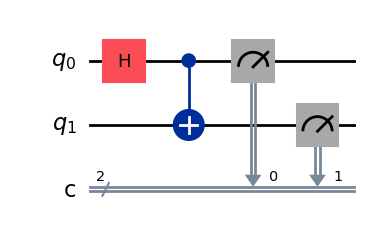


Circuit 2: H only on qubit 0


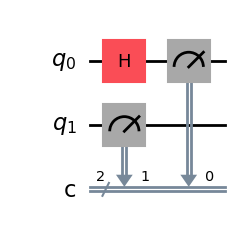

In [16]:
# a) Implement both circuits

# Circuit 1: H followed by CNOT (Bell state)
qc3a = QuantumCircuit(2, 2)
qc3a.h(0)
qc3a.cx(0, 1)
qc3a.measure([0, 1], [0, 1])

# Circuit 2: Only H on qubit 0
qc3b = QuantumCircuit(2, 2)
qc3b.h(0)
qc3b.measure([0, 1], [0, 1])

print("Circuit 1: H + CNOT (Bell State Circuit)")
display(qc3a.draw('mpl'))

print("\nCircuit 2: H only on qubit 0")
display(qc3b.draw('mpl'))

Circuit 1 (H + CNOT) counts: {'11': 538, '00': 486}
Circuit 2 (H only) counts: {'01': 508, '00': 516}


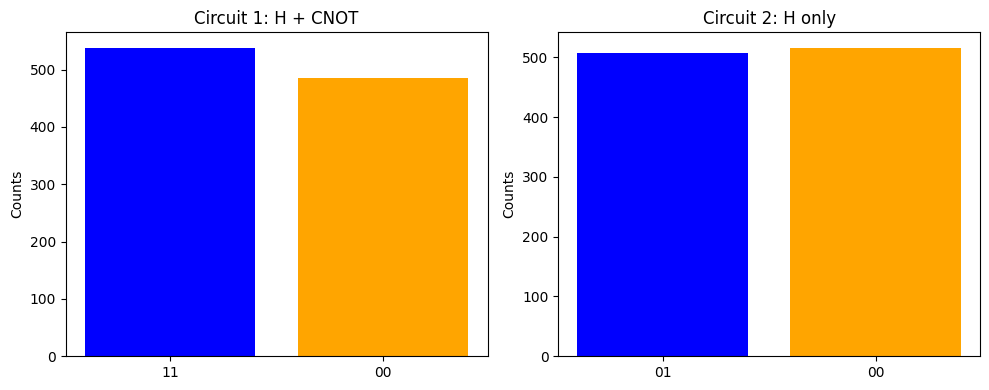

In [17]:
# b) Compare measurement outputs
sampler = StatevectorSampler()

# Run Circuit 1 (H + CNOT)
job1 = sampler.run([qc3a], shots=1024)
result1 = job1.result()
counts1 = result1[0].data.c.get_counts()

# Run Circuit 2 (H only)
job2 = sampler.run([qc3b], shots=1024)
result2 = job2.result()
counts2 = result2[0].data.c.get_counts()

print("Circuit 1 (H + CNOT) counts:", counts1)
print("Circuit 2 (H only) counts:", counts2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(counts1.keys(), counts1.values(), color=['blue', 'orange'])
axes[0].set_title('Circuit 1: H + CNOT')
axes[0].set_ylabel('Counts')
axes[1].bar(counts2.keys(), counts2.values(), color=['blue', 'orange', 'green', 'red'])
axes[1].set_title('Circuit 2: H only')
axes[1].set_ylabel('Counts')
plt.tight_layout()
plt.show()

### c) Which circuit produces entanglement?

**Circuit 1 (H + CNOT) produces entanglement.**

**Justification:**

- **Circuit 1** produces the Bell state: $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$
  - This is a maximally entangled state. It cannot be written as a tensor product of individual qubit states.
  - Measurement outcomes are perfectly correlated: we only observe $|00\rangle$ or $|11\rangle$.

- **Circuit 2** produces: $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes |0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$
  - This is a separable (product) state. The qubits are independent.
  - Qubit 0 is in superposition while qubit 1 is always $|0\rangle$.

### d) Role of CNOT in creating correlation

The CNOT (Controlled-NOT) gate flips the target qubit if and only if the control qubit is $|1\rangle$:

$$\text{CNOT}: |00\rangle \to |00\rangle, \quad |10\rangle \to |11\rangle$$

When the control qubit is in superposition (after H gate): $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)|0\rangle$

Applying CNOT:
$$\frac{1}{\sqrt{2}}(|00\rangle + |10\rangle) \xrightarrow{\text{CNOT}} \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

The CNOT creates a **conditional dependency** between the two qubits: the state of qubit 1 becomes correlated with qubit 0. This correlation is quantum entanglement — measuring one qubit instantly determines the other's state, regardless of distance.

---
## Problem 4: Reverse Engineering

**Goal:** Design a circuit that produces P(00) ≈ 0.5, P(11) ≈ 0.5

### a) & d) Circuit Design and Explanation

The target distribution $P(00) = P(11) = 0.5$ with $P(01) = P(10) = 0$ is exactly the **Bell state** $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$.

**Circuit:** Apply a Hadamard gate to qubit 0, then a CNOT gate with qubit 0 as control and qubit 1 as target.

**Step-by-step:**
1. Start: $|00\rangle$
2. After H on q0: $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)|0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$
3. After CNOT(q0→q1): $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

The probabilities are:
- $P(00) = |1/\sqrt{2}|^2 = 0.5$ ✓
- $P(11) = |1/\sqrt{2}|^2 = 0.5$ ✓
- $P(01) = P(10) = 0$ ✓

Problem 4: Bell State Circuit for P(00)=0.5, P(11)=0.5


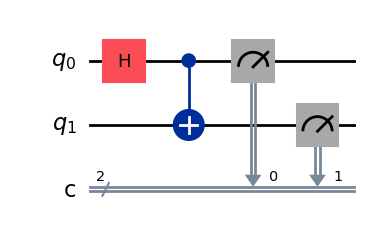

In [18]:
# b) Draw the circuit
qc4 = QuantumCircuit(2, 2)
qc4.h(0)
qc4.cx(0, 1)
qc4.measure([0, 1], [0, 1])

print("Problem 4: Bell State Circuit for P(00)=0.5, P(11)=0.5")
qc4.draw('mpl')

Measurement results (1024 shots):
{'11': 551, '00': 473}


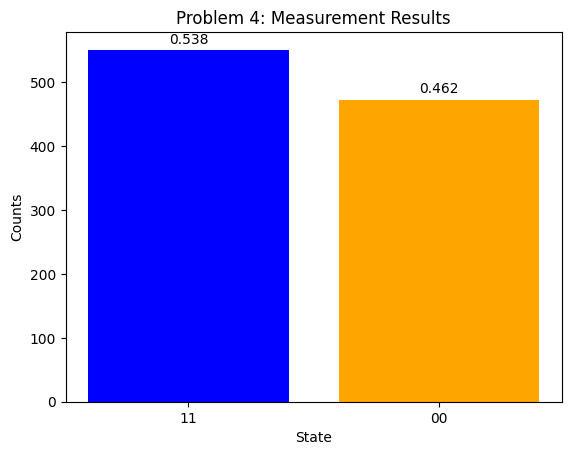


P(00) = 0.4619 (expected: 0.50)
P(11) = 0.5381 (expected: 0.50)
P(01) = 0.0000 (expected: 0.00)
P(10) = 0.0000 (expected: 0.00)


In [19]:
# c) Verify using simulation
sampler = StatevectorSampler()
job = sampler.run([qc4], shots=1024)
result = job.result()
counts = result[0].data.c.get_counts()

print("Measurement results (1024 shots):")
print(counts)

# Plot histogram
labels = list(counts.keys())
values = list(counts.values())
plt.bar(labels, values, color=['blue', 'orange', 'green', 'red'][:len(labels)])
plt.xlabel('State')
plt.ylabel('Counts')
plt.title('Problem 4: Measurement Results')
for i, v in enumerate(values):
    plt.text(i, v + 10, f'{v/1024:.3f}', ha='center')
plt.show()

print(f"\nP(00) = {counts.get('00', 0)/1024:.4f} (expected: 0.50)")
print(f"P(11) = {counts.get('11', 0)/1024:.4f} (expected: 0.50)")
print(f"P(01) = {counts.get('01', 0)/1024:.4f} (expected: 0.00)")
print(f"P(10) = {counts.get('10', 0)/1024:.4f} (expected: 0.00)")

### d) Explanation

The circuit produces the desired distribution because:

1. The **Hadamard gate** creates an equal superposition of $|0\rangle$ and $|1\rangle$ on qubit 0.
2. The **CNOT gate** then entangles the two qubits by flipping qubit 1 conditioned on qubit 0.
3. This creates the Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$, where the two qubits are always measured in the same state.
4. Since the superposition has equal amplitudes ($1/\sqrt{2}$), each outcome ($|00\rangle$ and $|11\rangle$) occurs with probability $0.5$.
5. The outcomes $|01\rangle$ and $|10\rangle$ have zero amplitude, so they never occur — the qubits are perfectly correlated due to entanglement.

---
## BITS Virtual Lab Snapshot

Screenshot from the BITS Virtual Lab demonstrating quantum circuit simulation:

In [ ]:
# Display the BITS Virtual Lab screenshot
from IPython.display import Image, display
import os

screenshot_path = "lab_snapshot.png"

if os.path.exists(screenshot_path):
    display(Image(filename=screenshot_path, width=700))
    print("BITS Virtual Lab - Quantum Circuit Simulation Screenshot")
else:
    print(f"NOTE: Please place your BITS Virtual Lab screenshot as '{screenshot_path}' in this folder.")
    print(f"Current folder: {os.getcwd()}")
    print("Then re-run this cell to display it.")